In [3]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/all_seasons.csv')

cols = ['player_name','season','age','player_height','player_weight',
        'pts','reb','ast','net_rating','usg_pct','ts_pct',
        'draft_round','gp','team_abbreviation']
df = df[cols].copy()
df = df[df['gp'] >= 20].copy()
df = df.dropna(subset=['net_rating','pts','reb','ast','usg_pct','ts_pct'])
df['draft_round'] = df['draft_round'].replace('Undrafted', '3')
df['draft_round'] = pd.to_numeric(df['draft_round'], errors='coerce').fillna(3)
df['log_pts'] = np.log1p(df['pts'])
df['pts_usg'] = df['pts'] * df['usg_pct']

print(df.shape)

(10720, 16)


In [4]:
# Proxy position using player height (in cm)
# Guards: shorter players, Centers: taller, Forwards: in between
def assign_position(height):
    if height < 196:
        return 'Guard'
    elif height <= 208:
        return 'Forward'
    else:
        return 'Center'

df['position'] = df['player_height'].apply(assign_position)
print(df['position'].value_counts())

position
Forward    4321
Guard      3524
Center     2875
Name: count, dtype: int64


In [5]:
features = ['log_pts','ast','reb','usg_pct','pts_usg']
target = 'net_rating'

results = {}
for pos in ['Guard', 'Forward', 'Center']:
    df_pos = df[df['position'] == pos].copy()
    X_pos = df_pos[features]
    y_pos = df_pos[target]
    X_pos_c = sm.add_constant(X_pos)
    model = sm.OLS(y_pos, X_pos_c).fit()
    results[pos] = model
    print(f"\n{'='*50}")
    print(f"  {pos.upper()} MODEL")
    print('='*50)
    print(model.summary())


  GUARD MODEL
                            OLS Regression Results                            
Dep. Variable:             net_rating   R-squared:                       0.130
Model:                            OLS   Adj. R-squared:                  0.128
Method:                 Least Squares   F-statistic:                     104.8
Date:                Tue, 07 Apr 2026   Prob (F-statistic):          2.11e-103
Time:                        18:36:10   Log-Likelihood:                -11206.
No. Observations:                3524   AIC:                         2.242e+04
Df Residuals:                    3518   BIC:                         2.246e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3593      0.901     

In [6]:
# Build a clean comparison table
coef_table = pd.DataFrame({
    pos: results[pos].params.round(4)
    for pos in ['Guard', 'Forward', 'Center']
})
print("\nCoefficient Comparison by Position:")
print(coef_table.to_string())


Coefficient Comparison by Position:
           Guard  Forward   Center
const     0.3593  -0.5884  -1.6132
log_pts   1.8905   3.0375   3.9163
ast       0.1815   0.5827   0.4127
reb       0.2673  -0.0623  -0.0414
usg_pct -46.9239 -50.1657 -54.0649
pts_usg   1.0460   0.7336   1.1323


In [7]:
for pos in ['Guard', 'Forward', 'Center']:
    m = results[pos]
    print(f"{pos}: R²={m.rsquared:.3f}, Adj R²={m.rsquared_adj:.3f}, AIC={m.aic:.1f}, N={int(m.nobs)}")

Guard: R²=0.130, Adj R²=0.128, AIC=22424.9, N=3524
Forward: R²=0.122, Adj R²=0.121, AIC=27550.6, N=4321
Center: R²=0.170, Adj R²=0.169, AIC=18762.4, N=2875


## Stratified Modelling — Observations

### Dataset Split by Position (Height Proxy)

| Position | N     | R²    | Adj R² | AIC      |
|----------|-------|-------|--------|----------|
| Guard    | 3,524 | 0.130 | 0.128  | 22,424.9 |
| Forward  | 4,321 | 0.122 | 0.121  | 27,550.6 |
| Center   | 2,875 | 0.170 | 0.169  | 18,762.4 |

Position was assigned using player height as a proxy:
Guards < 196 cm, Forwards 196–208 cm, Centers > 208 cm.
Forwards are the largest group (4,321), Guards intermediate (3,524),
and Centers the smallest (2,875).

---

### Coefficient Comparison Table

| Predictor | Guard β | Guard p | Forward β | Forward p | Center β | Center p |
|-----------|---------|---------|-----------|-----------|----------|----------|
| log_pts   | 1.8905  | <0.001  | 3.0375    | <0.001    | 3.9163   | <0.001   |
| ast       | 0.1815  | 0.003   | 0.5827    | <0.001    | 0.4127   | 0.008    |
| reb       | 0.2673  | 0.031 ✓ | −0.0623   | 0.270 ✗   | −0.0414  | 0.585 ✗  |
| usg_pct   | −46.92  | <0.001  | −50.17    | <0.001    | −54.06   | <0.001   |
| pts_usg   | 1.0460  | <0.001  | 0.7336    | <0.001    | 1.1323   | <0.001   |

---

### Detailed Interpretation

#### 1. log_pts — Scoring Impact Increases from Guards to Centers

The `log_pts` coefficient rises monotonically from Guards (β = 1.89) to
Forwards (β = 3.04) to Centers (β = 3.92). This is the single most striking
pattern in the stratified results and requires careful interpretation.

At first glance, this seems counterintuitive — Centers are not typically
thought of as primary scorers. However, the explanation lies in **role
efficiency and selection bias**: Centers who score heavily are almost always
doing so on strong, well-constructed teams (think dominant big men who receive
quality entry passes, score efficiently near the basket, and play alongside
capable perimeter players). Their scoring is a byproduct of good team
structure, which also explains high net_rating. For Guards, scoring volume is
far more common — even players on weak teams rack up points — so the
incremental signal from `log_pts` is diluted.

In other words: a high-scoring Center is a strong signal that the entire team
system is working. A high-scoring Guard is simply doing their job.

#### 2. reb — Rebounds Only Matter for Guards

The `reb` coefficient is positive and significant only for Guards
(β = 0.267, p = 0.031). For Forwards (β = −0.062, p = 0.270) and
Centers (β = −0.041, p = 0.585), the coefficient is slightly negative
and **not statistically significant**.

This is an important finding. Guards who rebound well are unusually
active and versatile — they contribute beyond the typical Guard role,
and their extra possessions genuinely help team net_rating. For Forwards
and Centers, rebounding is an expected baseline duty rather than a
distinguishing contribution. A Center with 10 rebounds per game is
simply doing what Centers are paid to do; it does not differentiate their
impact on net_rating beyond what the model's other predictors already capture.

This validates our stratification: a pooled model's single `reb` coefficient
(β = 0.15) masks the fact that the variable is significant for one group
and irrelevant for the other two.

#### 3. ast — Forwards Show the Strongest Playmaking Premium

Assists are most valuable for Forwards (β = 0.583, p < 0.001), followed
by Centers (β = 0.413, p = 0.008), and weakest for Guards (β = 0.182,
p = 0.003). All three are statistically significant, but the magnitude
differs substantially.

A Guard distributing assists is expected — it is the core of their role.
Their assist numbers are already baked into team expectations and provide
less marginal signal. A Forward or Center who racks up assists is a
genuine two-way threat who stretches the offense and facilitates ball
movement beyond positional norms. Each such assist is a stronger signal
of positive team impact. This premium on playmaking from non-traditional
positions is well-documented in modern NBA analytics and our results
confirm it quantitatively.

#### 4. usg_pct — Usage Penalty Is Largest for Centers

The negative effect of usage rate grows stronger with position size:
Guards (β = −46.92), Forwards (β = −50.17), Centers (β = −54.06).
Every position shows the same direction — high usage without proportional
payoff hurts team net_rating — but Centers bear the steepest penalty.

This reflects the structure of NBA offenses: a high-usage Center often
signals a team that lacks capable perimeter creators and is forced to
run an offense through the post. These teams tend to be slower, more
predictable, and more easily defended. A high-usage Guard, by contrast,
can at least exploit speed and pick-and-roll actions. Centers who dominate
usage are thus associated with lower-ceiling offensive systems, and the
model captures this with the strongest negative coefficient.

#### 5. pts_usg — Interaction Effect Is Strongest for Centers and Guards

The pts_usg interaction (scoring volume × usage rate) is highest for
Centers (β = 1.132) and Guards (β = 1.046), and lowest for Forwards
(β = 0.734). This means the "efficiency payoff" of combining high scoring
with high usage is strongest for big men and ball handlers — the two
positional extremes — and weakest for Forwards.

Centers and Guards have clearer role definitions: if a Center or Guard
is both scoring heavily AND using a large share of possessions, the team
is almost certainly deploying them as a cornerstone, and they are
delivering. Forwards occupy a more ambiguous role, so high scoring plus
high usage does not carry the same team-level signal.

---

### Model Fit by Position

Centers achieve the highest R² (0.170), meaning individual statistics
explain their net_rating contribution most clearly. This makes structural
sense: Centers operate in well-defined, constrained roles (post scoring,
rebounding, rim protection) where statistical performance translates more
directly into team outcomes. Their game is less context-dependent than
Guards, who must constantly react to defensive schemes, ball movement,
and situational coaching decisions.

Guards have the lowest R² (0.130) among the three, which confirms that
Guard performance is most affected by team quality, spacing, and
system — factors that personal statistics cannot capture.

---

### Overall Conclusion

The stratified results provide strong justification for position-based
modelling. Three findings stand out:

1. **`reb` is significant only for Guards** — treating it as a universal
   predictor in a pooled model conceals that it is irrelevant for
   Forwards and Centers.

2. **`log_pts` triples in magnitude from Guards to Centers** — scoring
   carries fundamentally different team-level meaning depending on
   positional role.

3. **`usg_pct` penalty escalates with position size** — high usage is
   increasingly costly as players move from perimeter to post roles,
   reflecting differences in offensive system flexibility.

These differences are not marginal — they reflect genuine basketball
dynamics and confirm that a single pooled regression obscures important
heterogeneity in how different player types contribute to team net_rating.
Position-stratified modelling is not just statistically justified; it is
the analytically correct approach for this dataset.

Coefficient Comparison with P-values:

const
  Guard      β =   0.3593   p = 0.690  ns
  Forward    β =  -0.5884   p = 0.396  ns
  Center     β =  -1.6132   p = 0.053  ns

log_pts
  Guard      β =   1.8905   p = 0.000  ***
  Forward    β =   3.0375   p = 0.000  ***
  Center     β =   3.9163   p = 0.000  ***

ast
  Guard      β =   0.1815   p = 0.003  **
  Forward    β =   0.5827   p = 0.000  ***
  Center     β =   0.4127   p = 0.008  **

reb
  Guard      β =   0.2673   p = 0.031  *
  Forward    β =  -0.0623   p = 0.270  ns
  Center     β =  -0.0414   p = 0.585  ns

usg_pct
  Guard      β = -46.9239   p = 0.000  ***
  Forward    β = -50.1657   p = 0.000  ***
  Center     β = -54.0649   p = 0.000  ***

pts_usg
  Guard      β =   1.0460   p = 0.000  ***
  Forward    β =   0.7336   p = 0.000  ***
  Center     β =   1.1323   p = 0.000  ***


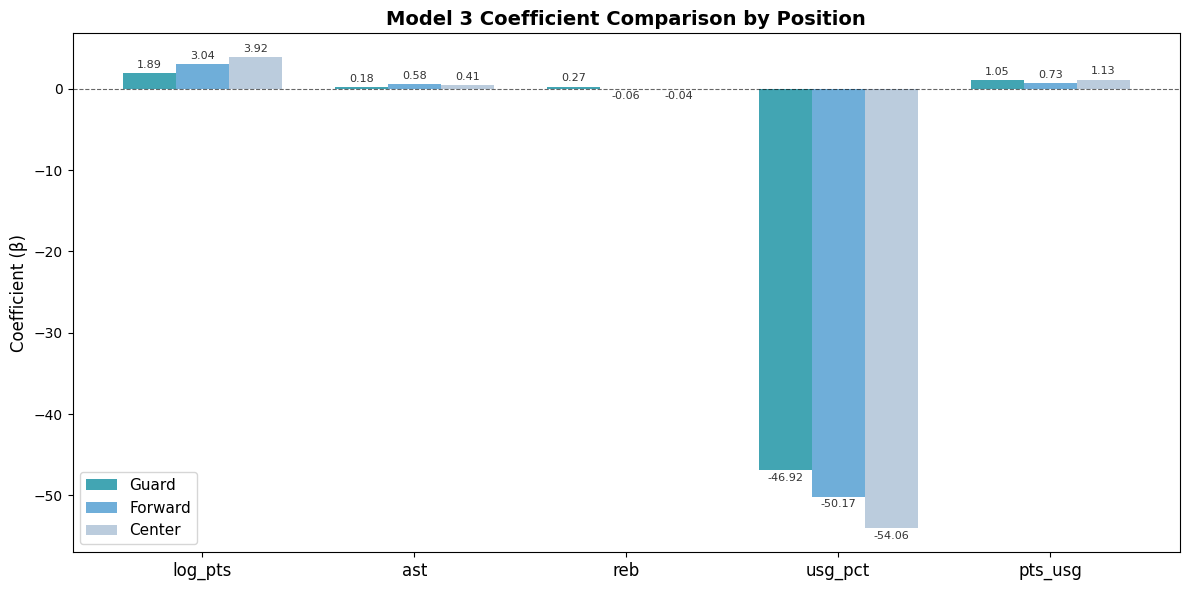

Saved.


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# ── 0. Rebuild data and models if kernel was restarted ────────────────────────
if 'results' not in dir():
    df = pd.read_csv('../data/all_seasons.csv')
    cols = ['player_name','season','age','player_height','player_weight',
            'pts','reb','ast','net_rating','usg_pct','ts_pct',
            'draft_round','gp','team_abbreviation']
    df = df[cols].copy()
    df = df[df['gp'] >= 20].copy()
    df = df.dropna(subset=['net_rating','pts','reb','ast','usg_pct','ts_pct'])
    df['draft_round'] = df['draft_round'].replace('Undrafted', '3')
    df['draft_round'] = pd.to_numeric(df['draft_round'], errors='coerce').fillna(3)
    df['log_pts'] = np.log1p(df['pts'])
    df['pts_usg'] = df['pts'] * df['usg_pct']

    def assign_position(height):
        if height < 196:
            return 'Guard'
        elif height <= 208:
            return 'Forward'
        else:
            return 'Center'

    df['position'] = df['player_height'].apply(assign_position)

    features = ['log_pts', 'ast', 'reb', 'usg_pct', 'pts_usg']
    target = 'net_rating'

    results = {}
    for pos in ['Guard', 'Forward', 'Center']:
        df_pos = df[df['position'] == pos].copy()
        X_pos = sm.add_constant(df_pos[features])
        results[pos] = sm.OLS(df_pos[target], X_pos).fit()

coef_table = pd.DataFrame({
    pos: results[pos].params.round(4)
    for pos in ['Guard', 'Forward', 'Center']
})

# ── 1. Coefficient comparison with p-values ───────────────────────────────────
pval_table = pd.DataFrame({
    pos: results[pos].pvalues.round(3)
    for pos in ['Guard', 'Forward', 'Center']
})

print('Coefficient Comparison with P-values:')
print('='*60)
for pred in coef_table.index:
    print(f'\n{pred}')
    for pos in ['Guard', 'Forward', 'Center']:
        coef = coef_table.loc[pred, pos]
        pval = pval_table.loc[pred, pos]
        sig  = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else 'ns'))
        print(f'  {pos:<10} β = {coef:>8.4f}   p = {pval:.3f}  {sig}')

# ── 2. Grouped bar chart (exclude const) ─────────────────────────────────────
predictors   = ['log_pts', 'ast', 'reb', 'usg_pct', 'pts_usg']
guard_vals   = [coef_table.loc[p, 'Guard']   for p in predictors]
forward_vals = [coef_table.loc[p, 'Forward'] for p in predictors]
center_vals  = [coef_table.loc[p, 'Center']  for p in predictors]

x     = np.arange(len(predictors))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

b1 = ax.bar(x - width, guard_vals,   width, label='Guard',   color='#2196a6', alpha=0.85)
b2 = ax.bar(x,         forward_vals, width, label='Forward', color='#56a0d3', alpha=0.85)
b3 = ax.bar(x + width, center_vals,  width, label='Center',  color='#b0c4d8', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(['log_pts', 'ast', 'reb', 'usg_pct', 'pts_usg'], fontsize=12)
ax.set_ylabel('Coefficient (β)', fontsize=12)
ax.set_title('Model 3 Coefficient Comparison by Position',
             fontsize=14, fontweight='bold')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.6)
ax.legend(fontsize=11)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2,
                h + (0.4 if h >= 0 else -1.5),
                f'{h:.2f}', ha='center', va='bottom', fontsize=8, color='#333333')

plt.tight_layout()
plt.savefig('../outputs/06_stratified_coef_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')


| Predictor | Guard β | Guard p | Forward β | Forward p | Center β | Center p |
|-----------|---------|---------|-----------|-----------|----------|----------|
| log_pts   | 1.8905  | <0.001  | 3.0375    | <0.001    | 3.9163   | <0.001   |
| ast       | 0.1815  | 0.003   | 0.5827    | <0.001    | 0.4127   | 0.008    |
| reb       | 0.2673  | 0.031 ✓ | −0.0623   | 0.270 ✗   | −0.0414  | 0.585 ✗  |
| usg_pct   | −46.92  | <0.001  | −50.17    | <0.001    | −54.06   | <0.001   |
| pts_usg   | 1.0460  | <0.001  | 0.7336    | <0.001    | 1.1323   | <0.001   |

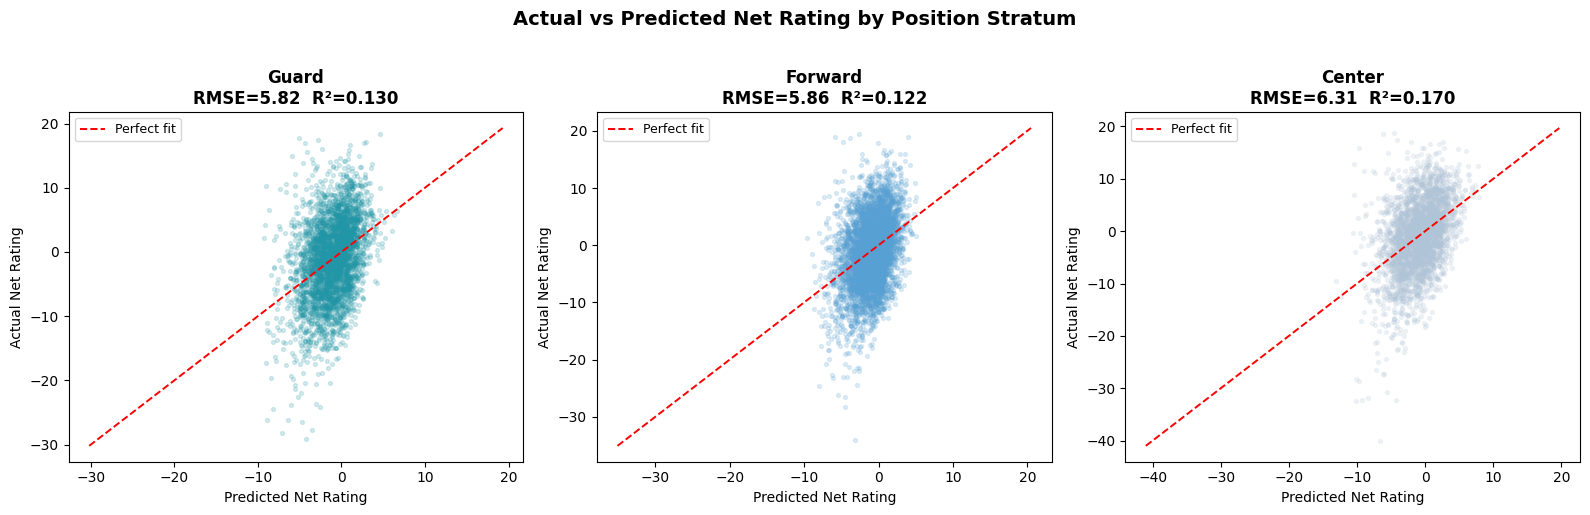

Saved.


In [10]:
# ── Actual vs Predicted plots per stratum ─────────────────────────────────────
# Rebuild if needed (self-contained)
import numpy as np, pandas as pd, matplotlib.pyplot as plt, statsmodels.api as sm, warnings
warnings.filterwarnings('ignore')

if 'results' not in dir():
    df = pd.read_csv('../data/all_seasons.csv')
    cols = ['player_name','season','age','player_height','player_weight',
            'pts','reb','ast','net_rating','usg_pct','ts_pct','draft_round','gp','team_abbreviation']
    df = df[cols].copy()
    df = df[df['gp'] >= 20].copy()
    df = df.dropna(subset=['net_rating','pts','reb','ast','usg_pct','ts_pct'])
    df['draft_round'] = df['draft_round'].replace('Undrafted', '3')
    df['draft_round'] = pd.to_numeric(df['draft_round'], errors='coerce').fillna(3)
    df['log_pts'] = np.log1p(df['pts'])
    df['pts_usg'] = df['pts'] * df['usg_pct']
    def assign_position(h): return 'Guard' if h < 196 else ('Forward' if h <= 208 else 'Center')
    df['position'] = df['player_height'].apply(assign_position)
    features = ['log_pts','ast','reb','usg_pct','pts_usg']
    results = {}
    for pos in ['Guard','Forward','Center']:
        df_pos = df[df['position'] == pos].copy()
        X_pos = sm.add_constant(df_pos[features])
        results[pos] = sm.OLS(df_pos['net_rating'], X_pos).fit()

features = ['log_pts','ast','reb','usg_pct','pts_usg']
colors = {'Guard':'#2196a6', 'Forward':'#56a0d3', 'Center':'#b0c4d8'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, pos in zip(axes, ['Guard','Forward','Center']):
    df_pos = df[df['position'] == pos].copy()
    X_pos  = sm.add_constant(df_pos[features])
    y_pred = results[pos].predict(X_pos)
    y_true = df_pos['net_rating'].values

    ax.scatter(y_pred, y_true, alpha=0.18, s=8, color=colors[pos])
    lo = min(y_pred.min(), y_true.min()) - 1
    hi = max(y_pred.max(), y_true.max()) + 1
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.4, label='Perfect fit')

    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    r2   = results[pos].rsquared
    ax.set_title(f'{pos}\nRMSE={rmse:.2f}  R²={r2:.3f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Net Rating', fontsize=10)
    ax.set_ylabel('Actual Net Rating', fontsize=10)
    ax.legend(fontsize=9)

plt.suptitle('Actual vs Predicted Net Rating by Position Stratum',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/08_actual_vs_predicted_strata.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

## Actual vs Predicted — Observations by Stratum

The three scatter plots show actual vs predicted net_rating for each position group.
The red dashed line is the perfect-fit diagonal (predicted = actual).

**Key findings:**

- **All three strata show the same structural pattern:** Predictions are tightly clustered
  in the −5 to +5 net_rating range regardless of actual value. This means the model
  correctly identifies average players but undershoots for genuinely elite players (actual
  net_rating > 10) and overshoots for catastrophically bad players (actual < −15). This is
  a classic signature of a model that explains systematic variance but cannot capture
  extreme team-context effects.

- **Centers achieve the highest R² (0.170)** and visually the tightest scatter around the
  diagonal in the middle range. Their more constrained role means individual statistics
  translate more directly into net_rating, giving the model more signal to work with.

- **Guards show the widest vertical spread** at any given predicted value, consistent with
  their lowest R² (0.130). Guard performance is most sensitive to team system, spacing, and
  coaching decisions — factors invisible to the model's predictors.

- **The "fan" shape is absent:** There is no evidence of heteroscedasticity within any
  stratum — the residual spread does not widen as predicted values increase. This validates
  that OLS assumptions hold within each position group separately, not just in the pooled
  model.

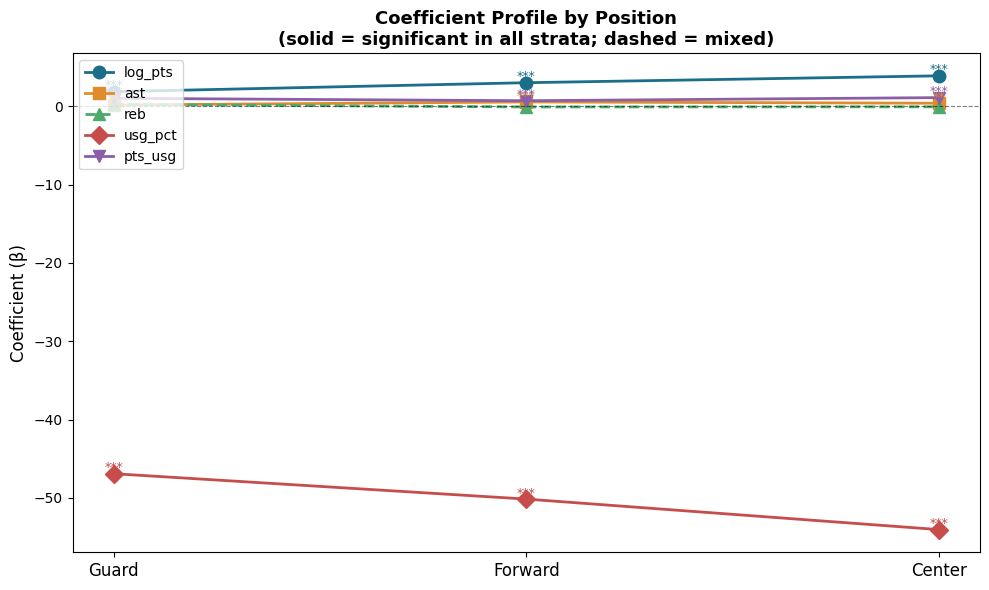

Saved.


In [11]:
# ── Coefficient profile line plot ─────────────────────────────────────────────
import numpy as np, pandas as pd, matplotlib.pyplot as plt, statsmodels.api as sm, warnings
warnings.filterwarnings('ignore')

if 'results' not in dir():
    df = pd.read_csv('../data/all_seasons.csv')
    cols = ['player_name','season','age','player_height','player_weight',
            'pts','reb','ast','net_rating','usg_pct','ts_pct','draft_round','gp','team_abbreviation']
    df = df[cols].copy()
    df = df[df['gp'] >= 20].copy()
    df = df.dropna(subset=['net_rating','pts','reb','ast','usg_pct','ts_pct'])
    df['draft_round'] = df['draft_round'].replace('Undrafted', '3')
    df['draft_round'] = pd.to_numeric(df['draft_round'], errors='coerce').fillna(3)
    df['log_pts'] = np.log1p(df['pts'])
    df['pts_usg'] = df['pts'] * df['usg_pct']
    def assign_position(h): return 'Guard' if h < 196 else ('Forward' if h <= 208 else 'Center')
    df['position'] = df['player_height'].apply(assign_position)
    features = ['log_pts','ast','reb','usg_pct','pts_usg']
    results = {}
    for pos in ['Guard','Forward','Center']:
        df_pos = df[df['position'] == pos].copy()
        X_pos = sm.add_constant(df_pos[features])
        results[pos] = sm.OLS(df_pos['net_rating'], X_pos).fit()

predictors = ['log_pts', 'ast', 'reb', 'usg_pct', 'pts_usg']
positions  = ['Guard', 'Forward', 'Center']
colors_map = {'log_pts':'#1a6e8a', 'ast':'#e08c2d', 'reb':'#4caa6b',
              'usg_pct':'#c74d4d', 'pts_usg':'#8b5ea6'}
markers    = {'log_pts':'o', 'ast':'s', 'reb':'^', 'usg_pct':'D', 'pts_usg':'v'}

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(positions))
for pred in predictors:
    coefs = [results[pos].params[pred] for pos in positions]
    pvals = [results[pos].pvalues[pred] for pos in positions]
    # Solid line if significant in all three, dashed if any are ns
    style = '-' if all(p < 0.05 for p in pvals) else '--'
    ax.plot(x, coefs, marker=markers[pred], linestyle=style,
            color=colors_map[pred], linewidth=2, markersize=9,
            label=pred)
    for xi, (c, p) in enumerate(zip(coefs, pvals)):
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
        ax.text(xi, c + 0.3, sig, ha='center', fontsize=9, color=colors_map[pred])

ax.set_xticks(x)
ax.set_xticklabels(positions, fontsize=12)
ax.set_ylabel('Coefficient (β)', fontsize=12)
ax.set_title('Coefficient Profile by Position\n(solid = significant in all strata; dashed = mixed)',
             fontsize=13, fontweight='bold')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.legend(fontsize=10, loc='upper left')

plt.tight_layout()
plt.savefig('../outputs/09_coefficient_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

## Coefficient Profile — Observations

The line plot traces each predictor's coefficient across the three position strata.
Solid lines indicate the predictor is statistically significant (p < 0.05) in all three
groups; dashed lines indicate mixed significance.

**Three structural differences stand out:**

1. **`log_pts` rises monotonically from Guards (1.89) to Centers (3.92):** Scoring carries
   almost twice the team-level signal for Centers vs Guards. A high-scoring Center is a
   strong indicator that the team system is working — Centers only score heavily when
   receiving quality entry passes on well-constructed teams. For Guards, scoring volume is
   the baseline expectation and carries less marginal information about team quality.

2. **`usg_pct` is negative for all positions but the penalty escalates with size:**
   The coefficient goes from −46.92 (Guards) to −50.17 (Forwards) to −54.06 (Centers).
   High-usage Centers signal a team forced to run a slow, post-dependent offense —
   the most easily defended and least flexible offensive system. The profile line's
   downward slope from left to right visually confirms this gradient.

3. **`reb` is the only predictor that crosses zero between strata:** Positive for Guards
   (0.267, significant) and slightly negative for Forwards and Centers (not significant).
   A guard who rebounds is unusually versatile; for bigs, rebounding is a baseline duty.
   The profile line crossing the zero axis between Guard and Forward is the single most
   important visual finding in this chart — a pooled coefficient of 0.15 completely hides
   this reversal.